# Dimensionality Reduction & PCA

**Dimensionality Reduction** is the technique of reducing the number of input variables (features) in your dataset while trying to preserve as much of the crucial, underlying structure (the "variance") as possible.

### Why do we reduce dimensions?
1. **The Curse of Dimensionality:** Machine learning algorithms start failing or hallucinating when they have too many features relative to the number of data points.
2. **Computational Speed:** Less data means lightning-fast training.
3. **Visualization:** We humans can only see in 2D or 3D. If your dataset has 500 features, plotting it is impossible unless you crush it down to 2 or 3 components!

---

## Principal Component Analysis (PCA)

PCA is a mathematical process that finds entirely new, orthogonal axes (called **Principal Components**) for your data. It rotates your data so that the first axis lies along the direction of maximum variance, the second axis points in the direction of the second most variance, and so on.

### The PCA Math (Step-by-Step)
1. **Standardize the Data:** Move the center of the data exactly to `(0,0)` by subtracting the mean.
2. **Compute the Covariance Matrix:** Calculate how every variable changes with every other variable. This mathematically maps out the "shape" of your data distribution.
3. **Calculate Eigenvectors and Eigenvalues:** This is the core magic! 
   * **Eigenvectors** point in the exact directions of the highest variance (the structural lines of your data).
   * **Eigenvalues** explain the *magnitude* of that variance (how important that direction is).
4. **Sort and Select:** Sort the Eigenvectors by their Eigenvalues from highest to lowest. If you want to reduce from 10D to 2D, you just keep the top 2 Eigenvectors.
5. **Transform (Project):** Mathematically project your original data onto those selected Eigenvectors!


In [2]:
import numpy as np
import matplotlib.pyplot as plt

class MyPCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.eigenvalues = None

    def fit(self, X):
        # 1. Standardize (Center the data)
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        # 2. Compute Covariance Matrix
        # Note: np.cov expects rows to be variables and columns to be observations by default,
        # so we transpose our standard X matrix.
        cov_matrix = np.cov(X_centered.T)
        
        # 3. Calculate Eigenvalues and Eigenvectors
        # eigh is highly optimized for symmetric matrices like Covariance matrices
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        # 4. Sort them in descending order mathematically
        # eigh sorts from smallest to largest by default, so we reverse it
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[sorted_indices]
        
        # Eigenvectors are stored as columns. We transpose so they are rows for easier math.
        sorted_eigenvectors = eigenvectors[:, sorted_indices]
        
        # Select the top n_components
        self.components = sorted_eigenvectors[:, :self.n_components].T

    def transform(self, X):
        # Center the data
        X_centered = X - self.mean
        # 5. Project the data! Dot product of centered data with the Eigenvectors.
        return np.dot(X_centered, self.components.T)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


## Live Example: Crushing 2D Data into 1D (Visually)

Let's generate a strongly correlated 2D dataset. Imagine this is predicting house prices: one axis is `Square_Footage`, the other is `Number_Of_Bedrooms`. Because they increase together, there's a strong diagonal line through the data.

PCA will find that diagonal line (the Eigenvector), and project every single point onto it, effectively crushing the 2D graph into a single 1D number-line!


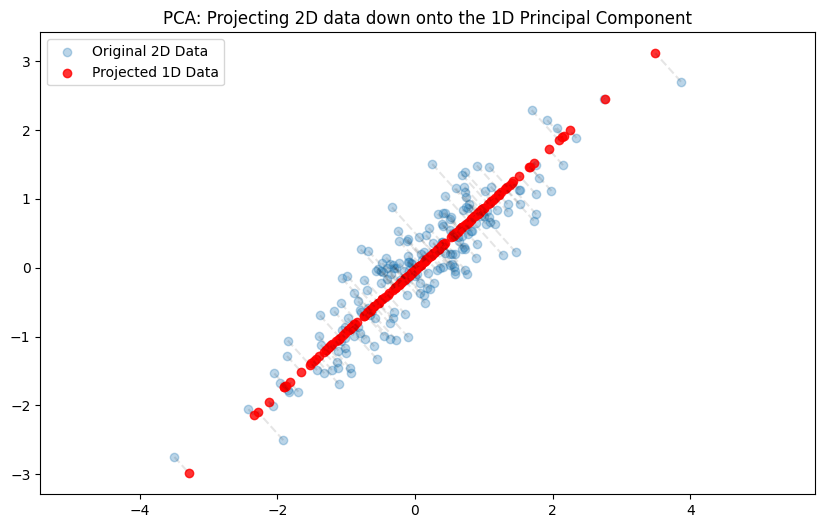

Notice how the red points perfectly capture the 'shape' (variance) of the data,
but they only require ONE number to describe their position on that red line, instead of TWO (x,y) coordinates!


In [3]:
# Generate 2D synthetic data that is stretched diagonally
np.random.seed(42)
X_synthetic = np.dot(np.random.rand(2, 2), np.random.randn(2, 200)).T

# Instantiate our custom PCA reducing from 2 to 1 dimension
my_pca = MyPCA(n_components=1)

# Fit and Transform!
X_projected_1d = my_pca.fit_transform(X_synthetic)

# To visualize what happened, let's reverse the transformation 
# to show where the 1D points sit in the original 2D space
X_reconstructed_2d = np.dot(X_projected_1d, my_pca.components) + my_pca.mean

# Plot
plt.figure(figsize=(10, 6))
# Original Data
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], alpha=0.3, label='Original 2D Data')

# Reconstructed Data (The 1D projection line)
plt.scatter(X_reconstructed_2d[:, 0], X_reconstructed_2d[:, 1], color='red', alpha=0.8, label='Projected 1D Data')

# Draw lines showing the physical crushing (projection)
for i in range(len(X_synthetic)):
    plt.plot([X_synthetic[i, 0], X_reconstructed_2d[i, 0]], 
             [X_synthetic[i, 1], X_reconstructed_2d[i, 1]], 'k--', alpha=0.1)

plt.title("PCA: Projecting 2D data down onto the 1D Principal Component")
plt.axis('equal')
plt.legend()
plt.show()

print("Notice how the red points perfectly capture the 'shape' (variance) of the data,")
print("but they only require ONE number to describe their position on that red line, instead of TWO (x,y) coordinates!")


## Live Example: Exploring Variance with Scikit-Learn

In industry, you will use `sklearn.decomposition.PCA`. A critical part of PCA is deciding *how many* dimensions to reduce down to. You can check the `explained_variance_ratio_` to see exactly what percentage of the original structural information is retained when you delete dimensions!


Original Dataset Shape: (1797, 64) (64 Dimensions)
Reduced Dataset Shape: (1797, 21) (2 Dimensions!)


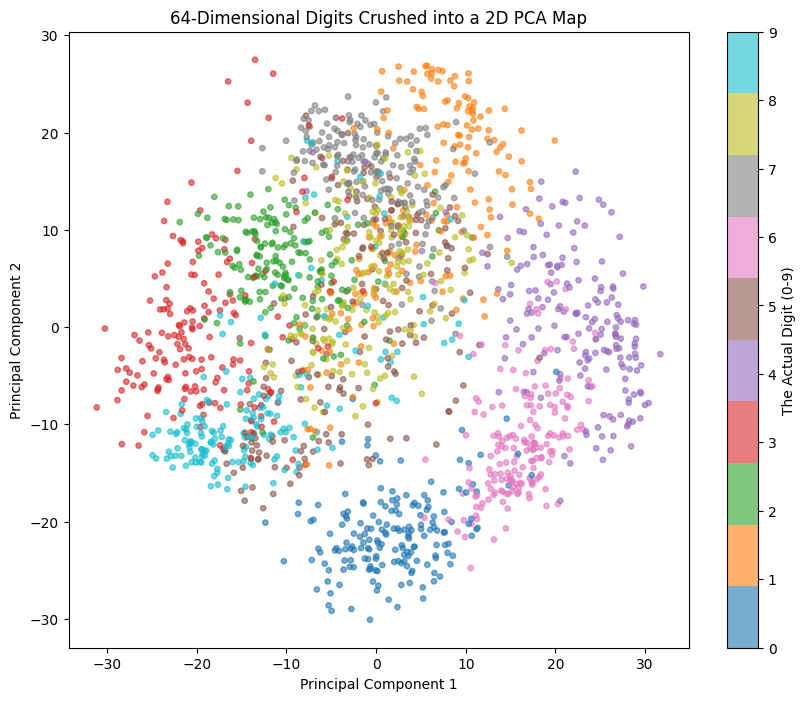

Variance explained by PC 1: 14.89%
Variance explained by PC 2: 13.62%
Total Information Retained: 90.32%

(Note: To confidently train an accurate ML model on this, you'd usually want to retain >90% variance. So you might need to keep the top ~20 Principal Components rather than just 2).


In [13]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

# Let's load the famous Digits dataset (8x8 pixel images of handwritten numbers)
# Each image has 64 pixels, so the dataset has 64 Dimensions!
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"Original Dataset Shape: {X_digits.shape} (64 Dimensions)")

# Let's crush 64 Dimensions down to just 2 Dimensions so we can visualize it!
sklearn_pca = PCA(n_components=0.9)
X_digits_2d = sklearn_pca.fit_transform(X_digits)

print(f"Reduced Dataset Shape: {X_digits_2d.shape} (2 Dimensions!)")

# Plot the 64-Dimensional numbers projected perfectly into 2D space!
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_digits_2d[:, 0], X_digits_2d[:, 1], c=y_digits, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='The Actual Digit (0-9)')
plt.title("64-Dimensional Digits Crushed into a 2D PCA Map")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# How much information did we preserve by keeping only 2 out of 64 dimensions?
var_ratio = sklearn_pca.explained_variance_ratio_
print(f"Variance explained by PC 1: {var_ratio[0]*100:.2f}%")
print(f"Variance explained by PC 2: {var_ratio[1]*100:.2f}%")
print(f"Total Information Retained: {np.sum(var_ratio)*100:.2f}%")
print("\n(Note: To confidently train an accurate ML model on this, you'd usually want to retain >90% variance. So you might need to keep the top ~20 Principal Components rather than just 2).")


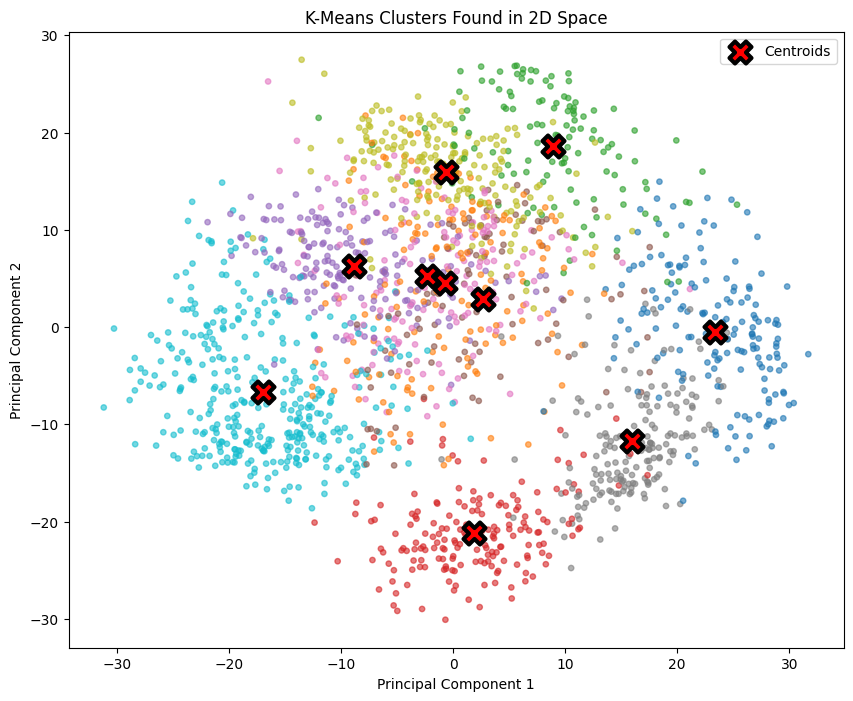

In [14]:
from sklearn.cluster import KMeans

# 1. Initialize KMeans with k=10 (since there are 10 digits, 0-9)
# We use n_init='auto' which automatically uses K-Means++ initialization!
kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')

# 2. Fit the model to the 2D PCA data and assign points to clusters
kmeans_labels = kmeans.fit_predict(X_digits_2d)

# 3. Get the coordinates of the 10 centroids found by K-Means
centroids = kmeans.cluster_centers_

# --- Plotting the K-Means Results ---
plt.figure(figsize=(10, 8))

# Plot the data points, colored by the cluster K-Means assigned them to
# (Notice we use `kmeans_labels` here, NOT the real `y_digits`)
plt.scatter(X_digits_2d[:, 0], X_digits_2d[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=15)

# Plot the centroids as big red X's
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=250, linewidths=3, edgecolor='black', label='Centroids')

plt.title("K-Means Clusters Found in 2D Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()
